hayek_ace_simulation.py
=======================
Simulación microestructural descentralizada para testear la Hipótesis de Hayek.

Arquitectura: Diseño Orientado a Datos (Vectorized OOP) con numpy.
Sin subastador walrasiano — el precio emerge de transacciones bilaterales
con información local e incompleta.

Hipótesis de Hayek (1945):
    El sistema de precios agrega y transmite información dispersa de manera
    eficiente sin requerir coordinación centralizada.

Referencias:
    - Hayek, F.A. (1945). The Use of Knowledge in Society. AER, 35(4).
    - Tesfatsion, L. (2006). Agent-Based Computational Economics: A Constructive
      Approach to Economic Theory. Handbook of Computational Economics, Vol. 2.
    - LeBaron, B. (2006). Agent-based Computational Finance. ibid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import NamedTuple, Callable

In [170]:
# ---------------------------------------------------------------------------
# Estructuras de datos inmutables
# ---------------------------------------------------------------------------
class Transaccion(NamedTuple):
    periodo: int
    id_consumidor: int
    id_productor: int
    precio: float
    cantidad: float

@dataclass
class EstadisticasPeriodo:
    periodo: int
    n_transacciones: int
    volumen_total: float
    precio_promedio: float
    precio_p025: float  # Antes precio_min
    precio_p975: float  # Antes precio_max
    inventario_destruido: float

# ---------------------------------------------------------------------------
# 1. SectorProductivo (Oferta Unidimensional)
# ---------------------------------------------------------------------------
class SectorProductivo:
    """
    Administra M productores heterogéneos. 
    Las firmas eligen su Precio basándose en memoria local y determinan 
    su producción pasivamente a través de su curva de oferta estructural.
    """
    def __init__(self, M: int, funcion_oferta: Callable[[np.ndarray], np.ndarray], precios_iniciales: np.ndarray, tau: int = 5, seed: int | None = None):
        self.rng = np.random.default_rng(seed)
        self.M = M
        self.tau = tau
        
        # Inyección de la función de oferta vectorizada
        self.funcion_oferta = funcion_oferta
        
        # Estado actual del precio
        self.precios = precios_iniciales.copy()
        
        # Estados operativos de mercado
        self.inventario = np.zeros(M, dtype=np.float64)
        self.produccion_actual = np.zeros(M, dtype=np.float64)
        self.ventas_actuales = np.zeros(M, dtype=np.float64)
        self.activo = np.ones(M, dtype=bool)

        # Memoria (Solo 2 variables: Precio y Beneficio)
        self.memoria_precios = np.tile(self.precios[:, None], (1, tau))
        self.memoria_beneficios = np.full((M, tau), -np.inf)

    def planificar_produccion(self) -> None:
        """
        Calcula la nueva producción. Las empresas inactivas (que decidieron salir)
        producen exactamente 0, evitando costos.
        """
        self.inventario.fill(0.0)
        self.ventas_actuales.fill(0.0)
        
        # La cantidad está dictada por la oferta, multiplicada por el vector de actividad (True=1, False=0)
        q_s = self.funcion_oferta(self.precios) * self.activo
        
        self.produccion_actual = q_s
        self.inventario += q_s

    def registrar_venta(self, id_productor: int, cantidad: float) -> None:
        self.ventas_actuales[id_productor] += cantidad

    def actualizar_precios_y_memoria(self, t: int, funcion_costo_total: Callable[[np.ndarray, np.ndarray], np.ndarray]) -> None:
        """
        Actualiza precios basándose puramente en la explotación del conocimiento histórico
        mediante una caminata aleatoria geométrica con corrección de deriva (Itô).
        Todas las firmas permanecen activas en cada periodo.
        """
        # 1. Contabilidad interna ex-post
        costos = funcion_costo_total(self.precios, self.produccion_actual)
        ingresos = self.precios * self.ventas_actuales
        beneficios = ingresos - costos

        # 2. Registrar estados en la memoria móvil
        idx = t % self.tau
        self.memoria_precios[:, idx] = self.precios
        self.memoria_beneficios[:, idx] = beneficios

        # 3. Extraer el mejor escenario histórico de cada firma en su ventana móvil
        mejores_periodos = np.argmax(self.memoria_beneficios, axis=1)
        mejores_precios = self.memoria_precios[np.arange(self.M), mejores_periodos]

        # 4. Decaimiento dinámico de la volatilidad (Sigma)
        sigma_actual = 0.05 #max(0.01, 0.05 - (t // 100) * 0.01)
        temblor_p = self.rng.normal(0, sigma_actual, self.M)
        
        nuevos_precios = np.zeros(self.M)

        # 5. Aplicación del choque geométrico neutrón a la deriva
        for j in range(self.M):
            if t < self.tau:
                # Inicialización del mercado: Schocks exploratorios iniciales amplios
                shock_inicial = self.rng.normal(0, 0.20) 
                nuevos_precios[j] = self.precios[j] * np.exp(shock_inicial)
            else:
                # Regla de Explotación pura con corrección de Itô sobre el mejor precio histórico
                nuevos_precios[j] = mejores_precios[j] * np.exp(temblor_p[j] - (sigma_actual**2 / 2))

        self.precios = np.clip(nuevos_precios, 1e-9, None)

    @property
    def indices_activos(self) -> np.ndarray:
        return np.where(self.activo & (self.inventario > 0.0))[0]


# ---------------------------------------------------------------------------
# 2. SectorConsumidor (Demanda Agnóstica)
# ---------------------------------------------------------------------------
class SectorConsumidor:
    """
    Administra N consumidores utilizando una función de demanda inyectada.
    """
    def __init__(self, N: int, funcion_demanda: Callable[[np.ndarray], np.ndarray]):
        self.N = N
        self.funcion_demanda = funcion_demanda

    def calcular_demanda(self, p_min: np.ndarray) -> np.ndarray:
        return self.funcion_demanda(p_min)


# ---------------------------------------------------------------------------
# 3. EntornoInstitucional (Mercado)
# ---------------------------------------------------------------------------
class EntornoInstitucional:
    def __init__(self, sector_productivo: SectorProductivo, sector_consumidor: SectorConsumidor, L: int = 5, seed: int | None = None):
        self.sp = sector_productivo
        self.sc = sector_consumidor
        self.L = L
        self.rng = np.random.default_rng(seed)
        self.periodo_actual = 0

        # Bitácoras de precios
        self.historial_periodos = []
        self.historial_precios_promedio = []
        self.historial_precios_equilibrio = []
        self.historial_precios_p025 = [] # Límite inferior (2.5%)
        self.historial_precios_p975 = [] # Límite superior (97.5%)

        # Bitácoras de cantidades
        self.historial_Q_ofertada = []      
        self.historial_Q_demandada = []     
        self.historial_Q_transada = []      
        self.historial_Q_neoclasica = []    

        # Bitácoras de bienestar
        self.historial_EC = []
        self.historial_EP = []
        self.historial_eficiencia = []

        self.historial_firmas_positivas = []
        self.historial_firmas_negativas = []
        
        # Pre-calcular Benchmark Neoclásico
        self.ec_teorico, self.ep_teorico, self.bienestar_teorico = self._estimar_bienestar_teorico()

    def _estimar_bienestar_teorico(self) -> tuple[float, float, float]:
        """Aproxima numéricamente el excedente máximo bajo vaciado walrasiano perfecto."""
        p_max_eval = 25.0  
        p_grid = np.linspace(0.01, p_max_eval, 2500)
        q_s_agg = np.zeros_like(p_grid)
        q_d_agg = np.zeros_like(p_grid)
        
        for k, p in enumerate(p_grid):
            q_s_agg[k] = np.sum(self.sp.funcion_oferta(np.full(self.sp.M, p)))
            q_d_agg[k] = np.sum(self.sc.calcular_demanda(np.full(self.sc.N, p)))
            
        idx_eq = np.argmin(np.abs(q_s_agg - q_d_agg))
        
        ep_max = np.trapz(q_s_agg[:idx_eq+1], p_grid[:idx_eq+1])
        ec_max = np.trapz(q_d_agg[idx_eq:], p_grid[idx_eq:])
        
        return ec_max, ep_max, ec_max + ep_max

    def _matching_vectorizado(self, periodo: int) -> list[Transaccion]:
        activos = self.sp.indices_activos
        n_activos = len(activos)

        if n_activos == 0:
            return []

        N = self.sc.N
        l_efectivo = min(self.L, n_activos)

        # 1. El consumidor toma su muestra aleatoria
        local_idx = np.stack([self.rng.choice(n_activos, size=l_efectivo, replace=False) for _ in range(N)])
        global_idx = activos[local_idx]

        # 2. Ordena las tiendas de su muestra desde la más barata a la más cara
        precios_muestra = self.sp.precios[global_idx]
        orden_precios = np.argsort(precios_muestra, axis=1)
        fila_idx = np.arange(N)[:, None]

        idx_prod_ordenado = global_idx[fila_idx, orden_precios]
        precios_ordenados = precios_muestra[fila_idx, orden_precios]

        # 3. PRE-CÁLCULO DINÁMICO: Calculamos la demanda teórica a CADA precio de la muestra
        q_demandada_matriz = self.sc.calcular_demanda(precios_ordenados)

        transacciones = []
        orden_llegada = self.rng.permutation(N)

        for i in orden_llegada:
            q_comprada_total = 0.0  # El consumidor entra con las manos vacías

            for rank in range(l_efectivo):
                j = idx_prod_ordenado[i, rank]
                p_t = precios_ordenados[i, rank]
                inv_j = self.sp.inventario[j]

                if inv_j <= 0.0:
                    continue # La tienda está vacía, camino a la siguiente.

                # 4. RACIONALIDAD ESTRICTA: Recalculo mi demanda total al nuevo precio
                q_deseada_a_este_precio = q_demandada_matriz[i, rank]
                
                # Mi necesidad real ahora es lo que deseo a este precio caro, 
                # MENOS lo que ya logré comprar barato.
                demanda_restante = q_deseada_a_este_precio - q_comprada_total

                # Si a este nuevo precio ya no quiero más (o quiero menos de lo que ya tengo), me retiro.
                if demanda_restante <= 1e-9:
                    break 

                # 5. Transacción efectiva
                q_transada = min(demanda_restante, inv_j)
                self.sp.inventario[j] -= q_transada
                self.sp.registrar_venta(j, q_transada)
                q_comprada_total += q_transada

                transacciones.append(Transaccion(
                    periodo=periodo, id_consumidor=int(i), id_productor=int(j),
                    precio=float(p_t), cantidad=float(q_transada)
                ))

        return transacciones

    def ejecutar_periodo(self, funcion_costo_total: Callable[[np.ndarray, np.ndarray], np.ndarray]) -> EstadisticasPeriodo:
        t = self.periodo_actual
        
        # 1. Fase de Producción
        self.sp.planificar_produccion()
        q_ofertada_total = float(self.sp.produccion_actual.sum()) 

        # 2. Captura de Demanda
        activos = self.sp.indices_activos
        n_activos = len(activos)
        
        if n_activos > 0:
            l_efectivo = min(self.L, n_activos)
            local_idx = np.stack([self.rng.choice(n_activos, size=l_efectivo, replace=False) for _ in range(self.sc.N)])
            global_idx = activos[local_idx]
            precios_muestra = self.sp.precios[global_idx]
            p_min = precios_muestra[np.arange(self.sc.N), np.argmin(precios_muestra, axis=1)]
            q_demandada_total = float(self.sc.calcular_demanda(p_min).sum()) 
        else:
            q_demandada_total = 0.0

        # Fase de Intercambio
        transacciones = self._matching_vectorizado(t)
        q_transada_total = float(sum(tx.cantidad for tx in transacciones)) 
        inventario_destruido = float(self.sp.inventario.sum())
        
        # 3. Benchmark Neoclásico
        p_eval_neoclasico = np.linspace(0.01, 5.0, 1000) 
        q_oferta_pot = np.zeros_like(p_eval_neoclasico)
        q_demanda_pot = np.zeros_like(p_eval_neoclasico)
        
        for idx_p, p in enumerate(p_eval_neoclasico):
            q_oferta_pot[idx_p] = np.sum(self.sp.funcion_oferta(np.full(self.sp.M, p)))
            q_demanda_pot[idx_p] = np.sum(self.sc.calcular_demanda(np.full(self.sc.N, p)))
            
        idx_eq = np.argmin(np.abs(q_oferta_pot - q_demanda_pot))
        p_eq_neoclasico = float(p_eval_neoclasico[idx_eq]) 
        q_eq_neoclasica = float(q_oferta_pot[idx_eq]) 

        # 4. Aprendizaje de los productores
        self.sp.actualizar_precios_y_memoria(t, funcion_costo_total)

        # 5. Computar precios estadísticos promedio
        if transacciones:
            precios_t = np.array([tx.precio for tx in transacciones])
            cant_t = np.array([tx.cantidad for tx in transacciones])
            p_prom = float(np.dot(precios_t, cant_t) / q_transada_total)
            
            # Intervalo empírico del 95% de los precios transados
            p_inf_t = float(np.percentile(precios_t, 2.5))
            p_sup_t = float(np.percentile(precios_t, 97.5))
        else:
            p_prom = p_eq_neoclasico
            p_inf_t = p_sup_t = p_eq_neoclasico

        # 6. Computar Bienestar Social Numérico Ex-Post
        idx_t = t % self.sp.tau
        ep_num = float(np.sum(self.sp.memoria_beneficios[:, idx_t]))
        
        q_comprada = np.zeros(self.sc.N)
        gasto_total = np.zeros(self.sc.N)
        for tx in transacciones:
            q_comprada[tx.id_consumidor] += tx.cantidad
            gasto_total[tx.id_consumidor] += tx.precio * tx.cantidad
            
        ec_num = 0.0
        if len(transacciones) > 0:
            p_promedio_pagado = np.where(q_comprada > 0, gasto_total / q_comprada, 0)
            p_max_int = max(20.0, float(np.max(p_promedio_pagado)) * 2)
            p_grid_ec = np.linspace(0.01, p_max_int, 300)
            q_grid_ec = np.zeros((300, self.sc.N))
            
            for k, p in enumerate(p_grid_ec):
                q_grid_ec[k, :] = self.sc.calcular_demanda(np.full(self.sc.N, p))
                
            for i in range(self.sc.N):
                q_i = q_comprada[i]
                if q_i > 0.0:
                    p_i = p_promedio_pagado[i]
                    idx_start = np.searchsorted(p_grid_ec, p_i)
                    if idx_start < len(p_grid_ec):
                        q_integrar = np.minimum(q_grid_ec[idx_start:, i], q_i)
                        ec_num += np.trapz(q_integrar, p_grid_ec[idx_start:])
                        
        bienestar_real = ec_num + ep_num
        eficiencia = (bienestar_real / self.bienestar_teorico) * 100.0 if self.bienestar_teorico > 0 else 0.0
        
        # 7. Alimentar Bitácoras
        self.historial_periodos.append(t)
        self.historial_precios_promedio.append(p_prom)
        self.historial_precios_equilibrio.append(p_eq_neoclasico)
        self.historial_precios_p025.append(p_inf_t)
        self.historial_precios_p975.append(p_sup_t)
        
        self.historial_Q_ofertada.append(q_ofertada_total)
        self.historial_Q_demandada.append(q_demandada_total)
        self.historial_Q_transada.append(q_transada_total)
        self.historial_Q_neoclasica.append(q_eq_neoclasica)
        
        self.historial_EC.append(ec_num)
        self.historial_EP.append(ep_num)
        self.historial_eficiencia.append(eficiencia)

        # Contabilidad demográfica de rentabilidad
        beneficios_del_periodo = self.sp.memoria_beneficios[:, idx_t]
        self.historial_firmas_positivas.append(int(np.sum(beneficios_del_periodo > 0)))
        self.historial_firmas_negativas.append(int(np.sum(beneficios_del_periodo <= 0)))

        stats = EstadisticasPeriodo(
            periodo=t, 
            n_transacciones=len(transacciones), 
            volumen_total=q_transada_total, 
            precio_promedio=p_prom, 
            precio_p025=p_inf_t,   # Inyectamos el percentil 2.5%
            precio_p975=p_sup_t,   # Inyectamos el percentil 97.5%
            inventario_destruido=inventario_destruido
        )
        self.periodo_actual += 1
        return stats

    # -----------------------------------------------------------------------
    # Métodos Analíticos y Gráficos
    # -----------------------------------------------------------------------
    def graficar_oferta_demanda(self, titulo: str = "Cruce Neoclásico") -> None:
        # 1. Anclar la gráfica al equilibrio estructural, no al ruido empírico
        p_eq = self.historial_precios_equilibrio[-1] if self.historial_precios_equilibrio else 1.0
        q_eq = self.historial_Q_neoclasica[-1] if self.historial_Q_neoclasica else 1.0
        
        # 2. Definir una ventana de precios sensata alrededor de P*
        p_min_eval = p_eq * 0.1
        p_max_eval = p_eq * 3.0
        rango_precios = np.linspace(p_min_eval, p_max_eval, 300)

        q_oferta_potencial = np.zeros_like(rango_precios)
        q_demanda_potencial = np.zeros_like(rango_precios)
        
        for idx_p, p in enumerate(rango_precios):
            q_oferta_potencial[idx_p] = np.sum(self.sp.funcion_oferta(np.full(self.sp.M, p)))
            q_demanda_potencial[idx_p] = np.sum(self.sc.calcular_demanda(np.full(self.sc.N, p)))

        plt.figure(figsize=(10, 6))
        
        # 3. Dibujar las curvas
        plt.plot(q_oferta_potencial, rango_precios, color='red', label='Oferta Agregada Teórica', linewidth=2.5)
        plt.plot(q_demanda_potencial, rango_precios, color='blue', label='Demanda Agregada Teórica', linewidth=2.5)
        
        # Líneas de proyección hacia los ejes
        plt.axhline(y=p_eq, color='gray', linestyle='--', alpha=0.5)
        plt.axvline(x=q_eq, color='gray', linestyle='--', alpha=0.5)
        
        # Punto de equilibrio exacto
        plt.scatter(q_eq, p_eq, color='black', zorder=5, s=120, label=f'Equilibrio Neoclásico: P*={p_eq:.2f}, Q*={q_eq:.0f}')

        plt.title(f"{titulo} - Periodo {self.periodo_actual}")
        plt.xlabel("Cantidad Agregada (Q)")
        plt.ylabel("Precio (P)")
        
        # 4. Bloquear dinámicamente los ejes para evitar la distorsión asintótica
        plt.xlim(0, q_eq * 2.5)
        plt.ylim(0, p_eq * 2.5)
        
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

    def graficar_tiempo_vs_precio(self) -> None:
        if not self.historial_periodos: return
        plt.figure(figsize=(12, 6))
        t = self.historial_periodos
        
        # Sombreado del intervalo empírico al 95%
        plt.fill_between(t, self.historial_precios_p025, self.historial_precios_p975, color='gray', alpha=0.25, label='Dispersión Transversal (IC 95%)')
        
        plt.plot(t, self.historial_precios_promedio, color='black', linestyle='-', linewidth=2.5, marker='o', markersize=3, label='Precio Promedio Real Transado (p̄)')
        plt.plot(t, self.historial_precios_equilibrio, color='blue', linestyle='--', linewidth=2, label='Precio de Equilibrio Teórico')

        plt.title("Evolución Temporal del Sistema de Precios")
        plt.xlabel("Periodo de Simulación (Tiempo t)")
        plt.ylabel("Precio (P)")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper right')
        plt.show()

    def graficar_cantidades_desagregadas(self) -> None:
        if not self.historial_periodos: return
        plt.figure(figsize=(12, 7))
        t = self.historial_periodos

        plt.plot(t, self.historial_Q_ofertada, color='orange', linestyle='-', linewidth=2, label='Cantidad Ofertada')
        plt.plot(t, self.historial_Q_demandada, color='purple', linestyle='-', linewidth=2, label='Cantidad Demandada')
        plt.plot(t, self.historial_Q_transada, color='forestgreen', linestyle='-', linewidth=2.5, label='Cantidad Transada Efectiva')
        plt.plot(t, self.historial_Q_neoclasica, color='darkblue', linestyle='--', linewidth=2.5, label='Cantidad Óptima Neoclásica')

        plt.title("Análisis Desagregado de Cantidades y Brechas de Mercado")
        plt.xlabel("Periodo de Simulación (Tiempo t)")
        plt.ylabel("Cantidad Agregada (Q)")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

In [172]:
def evaluar_convergencia_multimercado(mercados: list[EntornoInstitucional], ventana_T: int = 20, umbral_R: float = 1.1) -> tuple[float, bool]:
    """
    Aplica el criterio de Gelman-Rubin (R-hat) comparando las series de tiempo 
    del precio promedio real transado (p̄) de M mercados independientes en paralelo.
    
    Mide si las trayectorias macro de diferentes réplicas convergen al mismo consenso.
    """
    # Validar que todos los mercados hayan acumulado suficiente historia
    for m in mercados:
        if len(m.historial_precios_promedio) < ventana_T:
            return 1.5, False # Aún no hay suficiente historia para evaluar

    # 1. Extraer los últimos T precios promedio de cada mercado (Las M cadenas)
    # Cada fila representará la historia reciente de un mercado independiente
    cadenas_precios = np.array([m.historial_precios_promedio[-ventana_T:] for m in mercados]) # (M, T)
    M_mercados, T_tiempos = cadenas_precios.shape

    # 2. Varianza Intra-cadena (W): Promedio de las varianzas temporales de cada mercado
    varianzas_internas = np.var(cadenas_precios, axis=1, ddof=1) # ddof=1 para varianza muestral
    W = np.mean(varianzas_internas)

    # 3. Varianza Entre-cadenas (B): Varianza de los promedios de cada mercado
    promedios_mercados = np.mean(cadenas_precios, axis=1)
    # Multiplicamos por T_tiempos para escalar la varianza de las medias según la teoría de muestreo
    B = T_tiempos * np.var(promedios_mercados, ddof=1)

    # 4. Estimación de la Varianza Marginal Total de la población (Var_Plus)
    # Es un promedio ponderado que corrige el sesgo del tamaño de la muestra temporal
    var_plus = ((T_tiempos - 1) / T_tiempos) * W + (1.0 / T_tiempos) * B

    # 5. Calcular el estadístico R-hat
    # Si los mercados están dispersos o divergen, var_plus >> W y R-hat > 1.1
    if W == 0.0:
        r_hat = 1.0
    else:
        r_hat = np.sqrt(var_plus / W)

    ha_convergido = r_hat <= umbral_R
    return float(r_hat), ha_convergido

In [238]:
# ---------------------------------------------------------------------------
# Bloque Principal de Configuración (Monousuario / Un Mercado)
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    rng_cfg = np.random.default_rng(42)
    
    N, M, L, TAU, T_MAX = 1000, 1, 3, 10, 500
    mercados = []

    # Parámetros Base
    epsilon_s = 0.2
    epsilon_d = -1.2
    A_heterogeneo = rng_cfg.lognormal(mean=0.0, sigma=0.5, size=M)
    B_heterogeneo = rng_cfg.lognormal(mean=0.0, sigma=0.5, size=N)

    precios_iniciales = [rng_cfg.uniform(0.1, 0.4, size=M), rng_cfg.uniform(2, 4, size=M), rng_cfg.uniform(5, 7, size=M) ]

    # Funciones inyectables
    def oferta_isoelastica(precios: np.ndarray) -> np.ndarray:
        # Si la firma proyecta escenarios en matriz (2D)
        if precios.ndim == 2:
            return A_heterogeneo[:, None] * (precios ** epsilon_s)
        # Evaluacion unidimensional clásica
        return A_heterogeneo * (precios ** epsilon_s)

    def demanda_isoelastica(precios: np.ndarray) -> np.ndarray:
        # Si el consumidor evalúa una muestra de tiendas simultáneamente (2D)
        if precios.ndim == 2:
            return B_heterogeneo[:, None] * (precios ** epsilon_d)
        # Evaluacion unidimensional clásica
        return B_heterogeneo * (precios ** epsilon_d)

    def costo_total_tecnologico(precios: np.ndarray, produccion: np.ndarray, A=A_heterogeneo) -> np.ndarray:
        """
        Calcula el costo físico de producción basándose estrictamente en Q y la tecnología A.
        Ignora el vector 'precios' que la firma decidió cobrar nominalmente.
        """
        # Evitar divisiones por cero o potencias de números negativos
        prod_segura = np.clip(produccion, 1e-9, None)
        
        # Ajuste estructural por si en el futuro vectorizas proyecciones de múltiples periodos
        A_calc = A[:, None] if prod_segura.ndim == 2 else A
        
        # CMg(Q) = (Q / A)^(1/epsilon_s)
        costo_marginal_implicito = (prod_segura / A_calc) ** (1.0 / epsilon_s)
        
        # Integral del CMg para obtener Costo Total
        costos = (costo_marginal_implicito * prod_segura) / (1.0 + 1.0 / epsilon_s)
        return costos

    # Instanciación
    for i in range(3):
        sp = SectorProductivo(M=M, funcion_oferta=oferta_isoelastica, precios_iniciales=precios_iniciales[i], tau=TAU, seed=44 + i)
        sc = SectorConsumidor(N=N, funcion_demanda=demanda_isoelastica)
        mercado = EntornoInstitucional(sp, sc, L=L, seed = 46 + i)
        mercados.append(mercado)

    # Ejecución
    print("Ejecutando simulación base...")
    for t in range(T_MAX):
        for i in range(3):
            stats = mercados[i].ejecutar_periodo(funcion_costo_total=costo_total_tecnologico)
        if t % 100 == 0:
            print(f"t={stats.periodo:02d} | p̄={stats.precio_promedio:.3f} | Q_transada={stats.volumen_total:>8.2f} | Mermas={stats.inventario_destruido:>8.2f}")

Ejecutando simulación base...


C:\Users\Dccs2\AppData\Local\Temp\ipykernel_6396\697723847.py:309: RuntimeWarning: invalid value encountered in divide
  p_promedio_pagado = np.where(q_comprada > 0, gasto_total / q_comprada, 0)


t=00 | p̄=5.880 | Q_transada=    1.66 | Mermas=    0.00
t=100 | p̄=45.237 | Q_transada=    2.50 | Mermas=    0.00
t=200 | p̄=146.894 | Q_transada=    2.79 | Mermas=    0.37
t=300 | p̄=129.348 | Q_transada=    3.08 | Mermas=    0.00
t=400 | p̄=128.857 | Q_transada=    3.08 | Mermas=    0.00


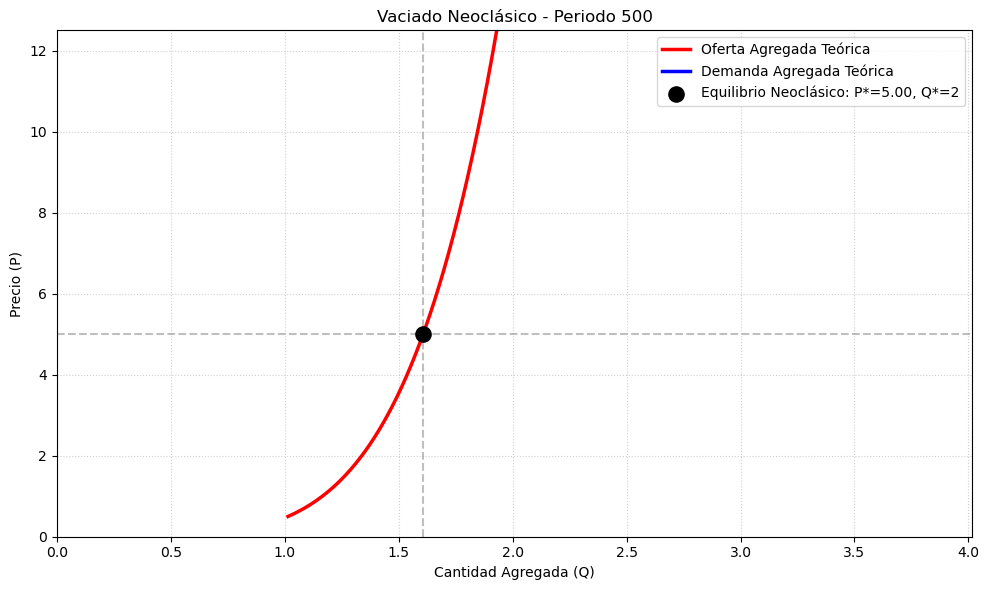

In [239]:
mercados[0].graficar_oferta_demanda("Vaciado Neoclásico")

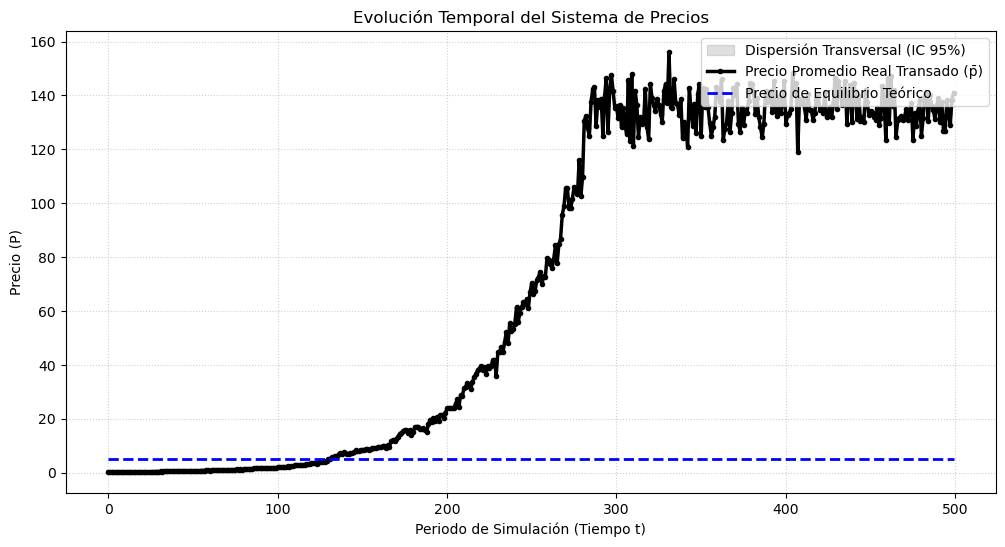

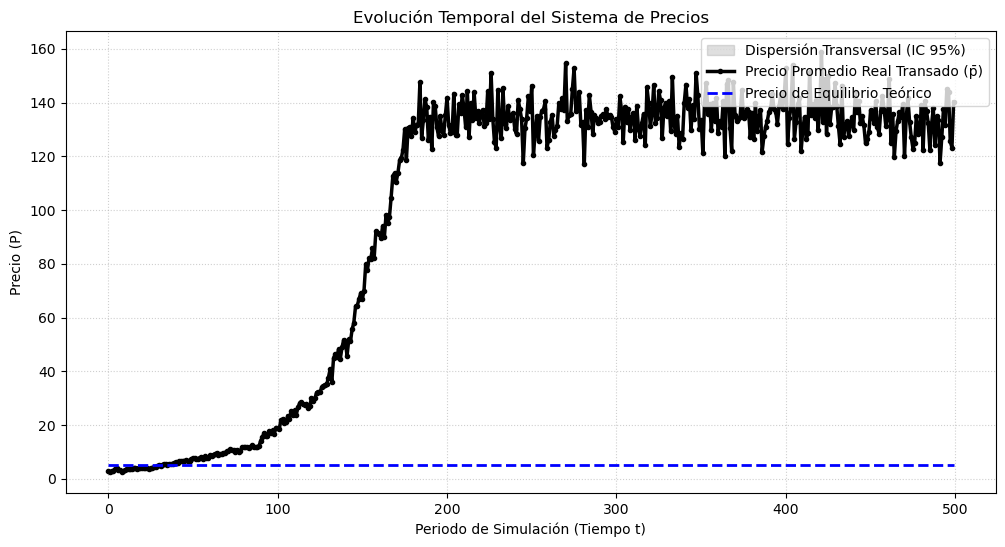

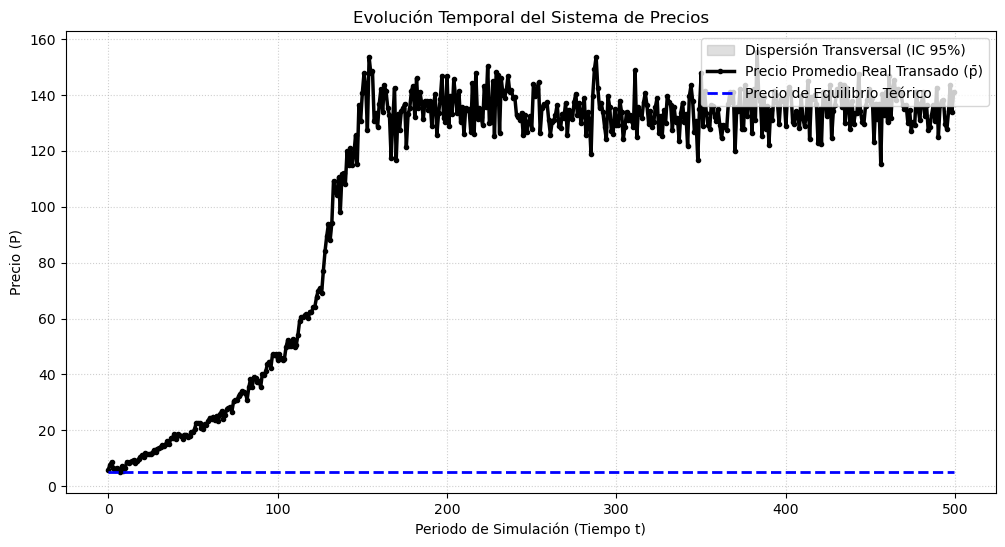

In [240]:
for i in range(3):
    mercados[i].graficar_tiempo_vs_precio()

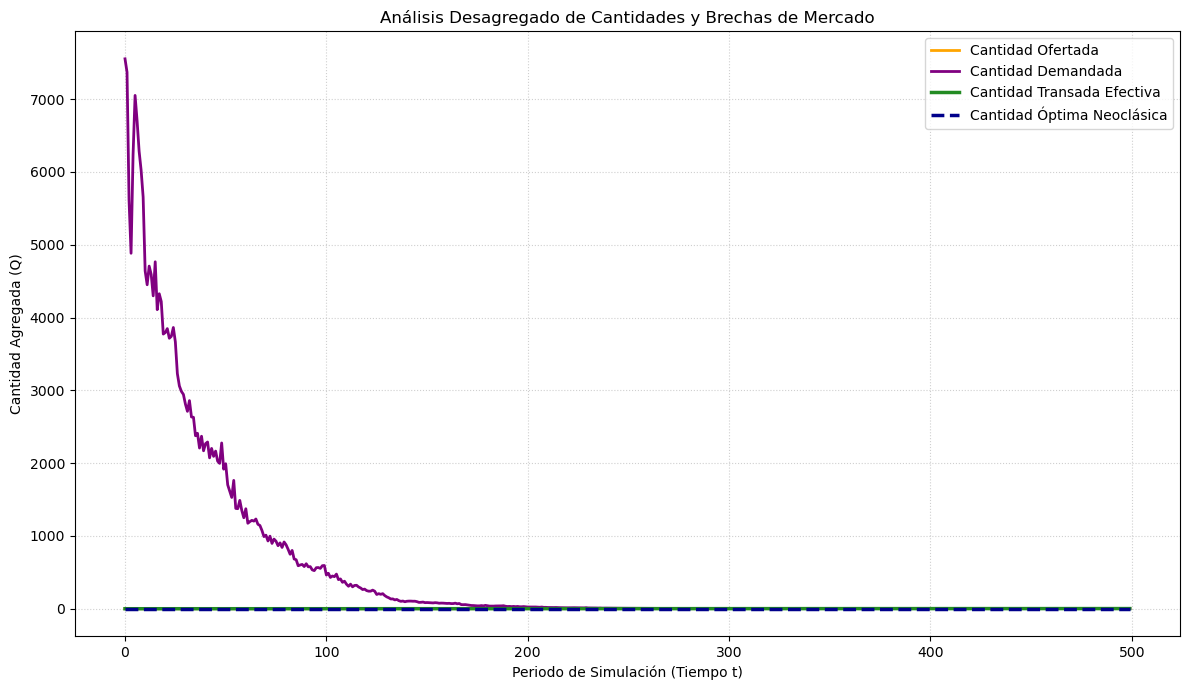

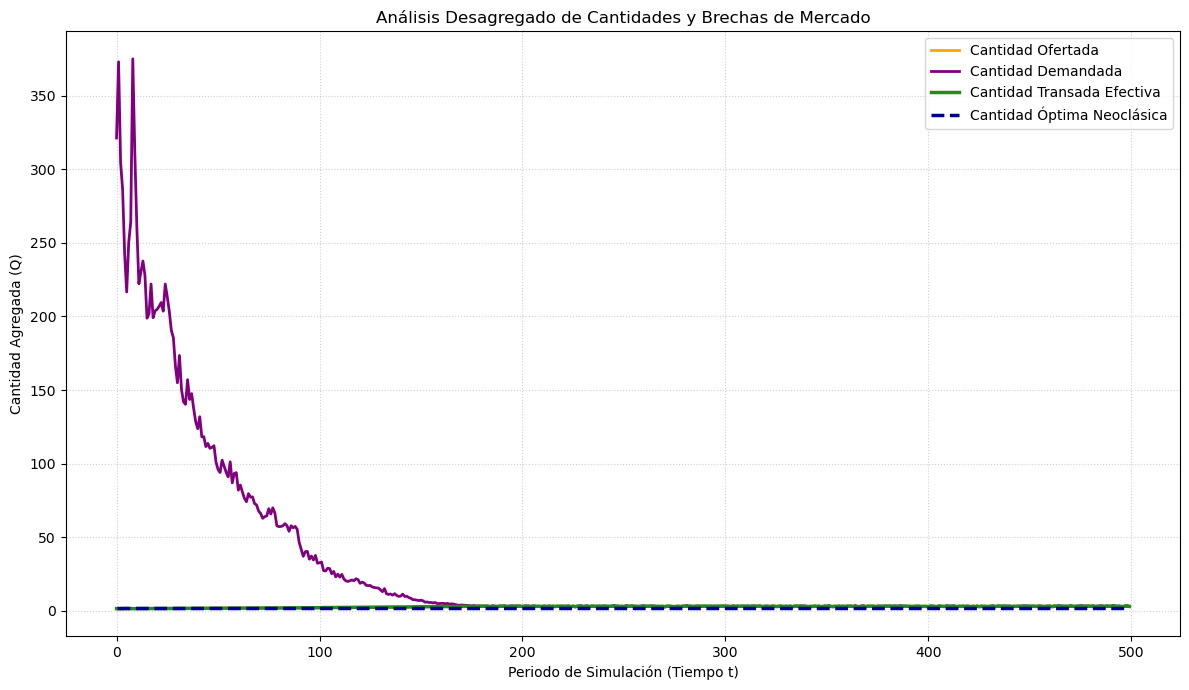

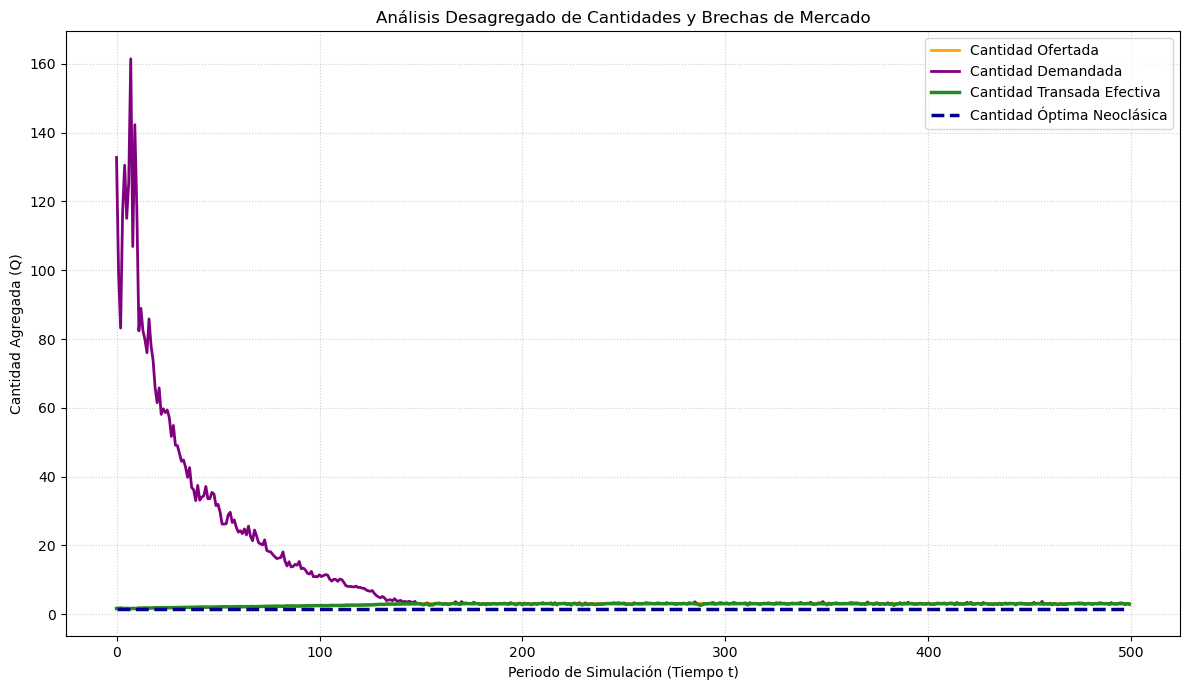

In [241]:
for i in range(3):
    mercados[i].graficar_cantidades_desagregadas()

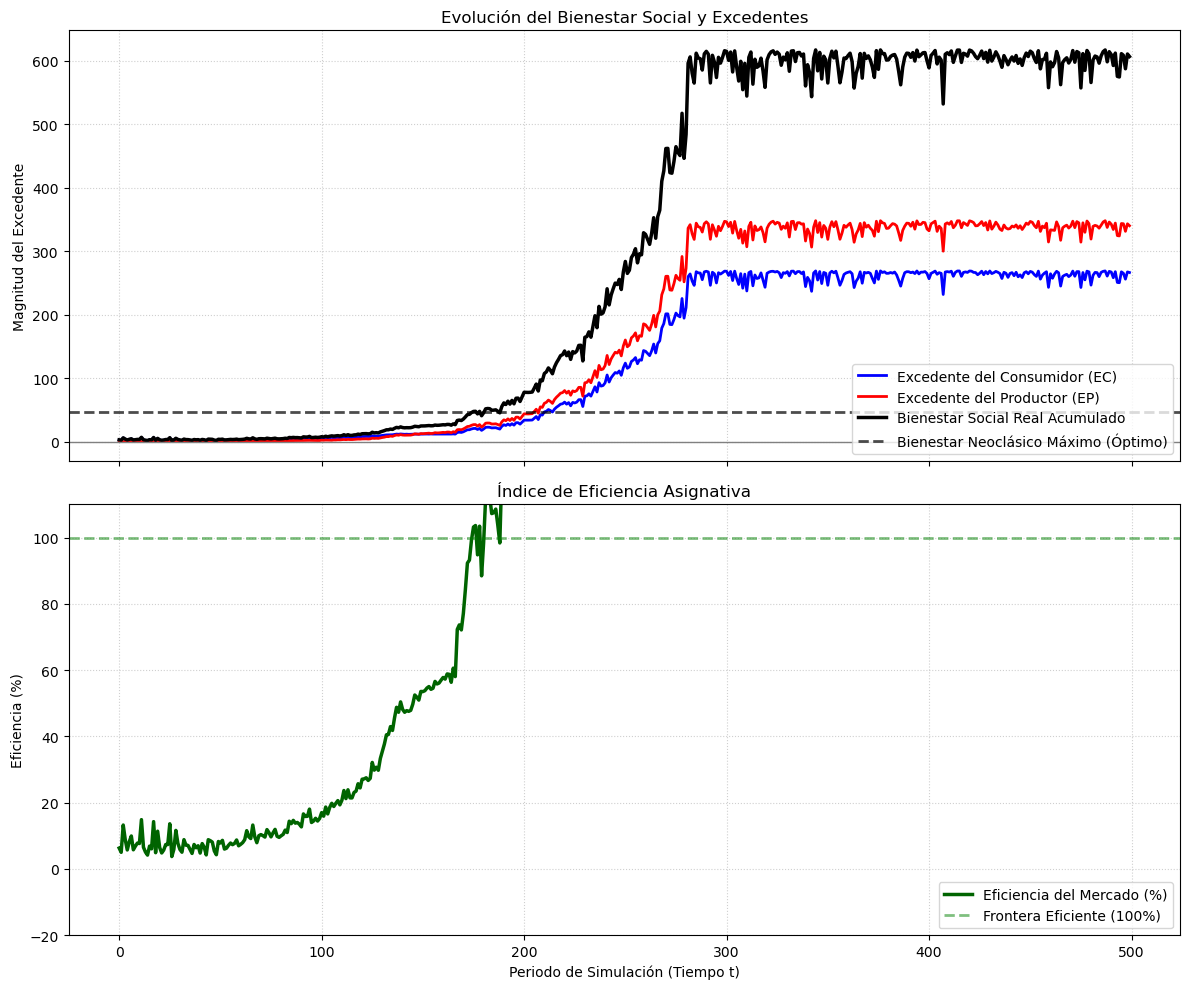

In [242]:
# Extraemos la instancia específica del mercado
m = mercados[0]
t = m.historial_periodos

# Creamos la figura con dos paneles compartiendo el eje X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# ---------------------------------------------------------------------------
# Panel 1: Desagregación del Bienestar Social (Excedentes)
# ---------------------------------------------------------------------------
ax1.plot(t, m.historial_EC, color='blue', linewidth=2, label='Excedente del Consumidor (EC)')
ax1.plot(t, m.historial_EP, color='red', linewidth=2, label='Excedente del Productor (EP)')

# Suma del bienestar real ex-post
bienestar_real = np.array(m.historial_EC) + np.array(m.historial_EP)
ax1.plot(t, bienestar_real, color='black', linewidth=2.5, linestyle='-', label='Bienestar Social Real Acumulado')

# Líneas base de referencia
ax1.axhline(y=m.bienestar_teorico, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Bienestar Neoclásico Máximo (Óptimo)')
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=1) # Línea de quiebra

ax1.set_title("Evolución del Bienestar Social y Excedentes")
ax1.set_ylabel("Magnitud del Excedente")
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower right')

# ---------------------------------------------------------------------------
# Panel 2: Índice de Eficiencia Asignativa
# ---------------------------------------------------------------------------
ax2.plot(t, m.historial_eficiencia, color='darkgreen', linewidth=2.5, label='Eficiencia del Mercado (%)')
ax2.axhline(y=100.0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Frontera Eficiente (100%)')

ax2.set_title("Índice de Eficiencia Asignativa")
ax2.set_xlabel("Periodo de Simulación (Tiempo t)")
ax2.set_ylabel("Eficiencia (%)")

# Ajuste dinámico del límite inferior por si hay pérdidas masivas al inicio
limite_inferior = min(-20, min(m.historial_eficiencia) * 1.1) if m.historial_eficiencia else 0
ax2.set_ylim(limite_inferior, 110)

ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

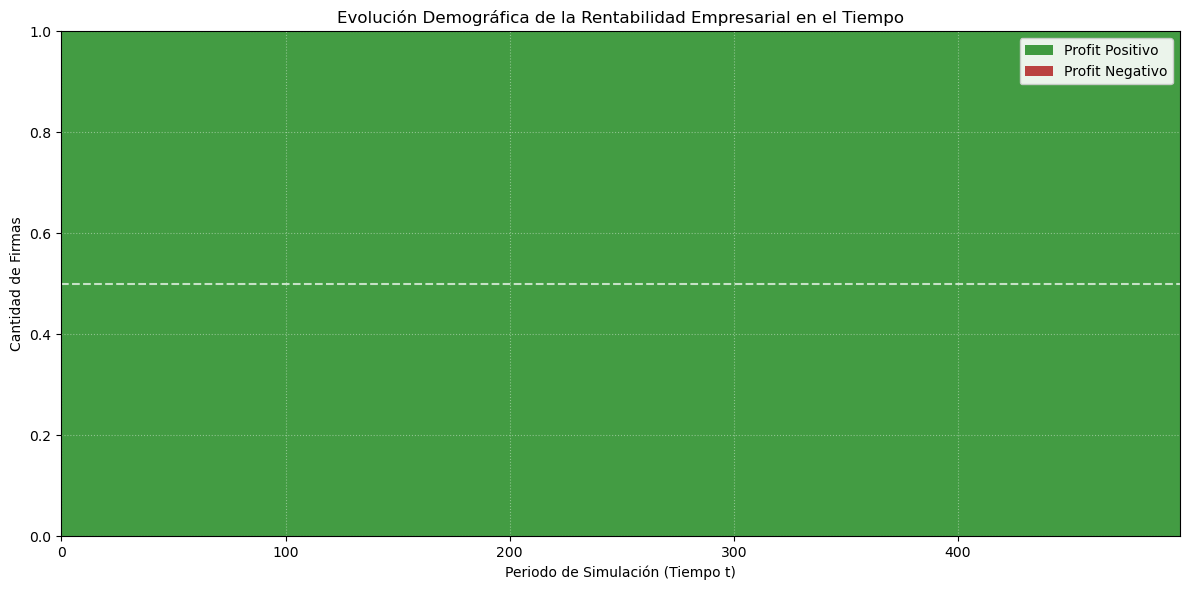

In [243]:
# Extraemos la instancia
m = mercados[0]
t = m.historial_periodos

positivas = np.array(m.historial_firmas_positivas)
negativas = np.array(m.historial_firmas_negativas)

plt.figure(figsize=(12, 6))

# Gráfico de áreas apiladas para ver la proporción exacta sobre el total M
plt.stackplot(t, positivas, negativas, 
              labels=['Profit Positivo', 'Profit Negativo'],
              colors=['forestgreen', 'firebrick'], 
              alpha=0.85)

# Línea de referencia del 50% del mercado
M_total = m.sp.M
plt.axhline(y=M_total / 2, color='white', linestyle='--', linewidth=1.5, alpha=0.7)

plt.title("Evolución Demográfica de la Rentabilidad Empresarial en el Tiempo")
plt.xlabel("Periodo de Simulación (Tiempo t)")
plt.ylabel("Cantidad de Firmas")

# Forzar el eje Y para que calce exacto con el total de empresas (M)
plt.ylim(0, M_total)
plt.xlim(t[0], t[-1])

plt.grid(True, linestyle=':', alpha=0.4, color='white')
plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.show()

In [244]:
# ---------------------------------------------------------------------------
# CÁLCULO DEL PRECIO TEÓRICO DEDUCIDO (VERIFICACIÓN ANALÍTICA)
# ---------------------------------------------------------------------------
# 1. Parámetro de rigidez estructural (gamma)
gamma = 1.0 / (epsilon_s - epsilon_d)

# 2. Equilibrio Neoclásico Analítico (P*)
A_total = np.sum(A_heterogeneo)
B_total = np.sum(B_heterogeneo)
P_neoclasico_analitico = (B_total / A_total) ** gamma

# 3. Vector de Precios Heurísticos por Firma (Mapeo Jerárquico)
A_sorted = np.sort(A_heterogeneo)  # De menor capacidad a mayor capacidad
A_mean = np.mean(A_heterogeneo)

# Posición en el ranking (1 a M). 
# Usamos una corrección de continuidad empírica (m - 0.5) para evitar 
# que el límite absoluto (m=1) de un precio igual a cero estropee la media.
m_ranks = np.arange(1, M + 1)
fraccion_mas_caras = (m_ranks - 0.5) / M  

# Ecuación estructural exacta
P_firmas_analitico = P_neoclasico_analitico * ((A_mean / A_sorted) ** gamma) * (L ** gamma) * (fraccion_mas_caras ** (gamma * (L - 1)))

# 4. Precio Promedio Esperado
P_promedio_heuristico = np.mean(P_firmas_analitico)

print("\n=== VERIFICACIÓN ESTRUCTURAL EX-ANTE ===")
print(f"P* Neoclásico Analítico        : {P_neoclasico_analitico:.3f}")
print(f"P Promedio Heurístico (L={L:<2})  : {P_promedio_heuristico:.3f}")
print("========================================\n")


=== VERIFICACIÓN ESTRUCTURAL EX-ANTE ===
P* Neoclásico Analítico        : 134.510
P Promedio Heurístico (L=3 )  : 109.525

